<a href="https://colab.research.google.com/github/ayesha0859/DL/blob/main/DL3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part a) Neural Network Design

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
model = keras.Sequential([
    layers.Dense(units=64, activation='relu', input_shape=[10]),
    layers.Dense(units=32, activation='relu'),
    layers.Dense(units=1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,817 (11.00 KB)

 Trainable params: 2,817 (11.00 KB)

 Non-trainable params: 0 (0.00 B)

None


### Part b) Plotting the Model

In [ ]:
from tensorflow.keras.utils import plot_model

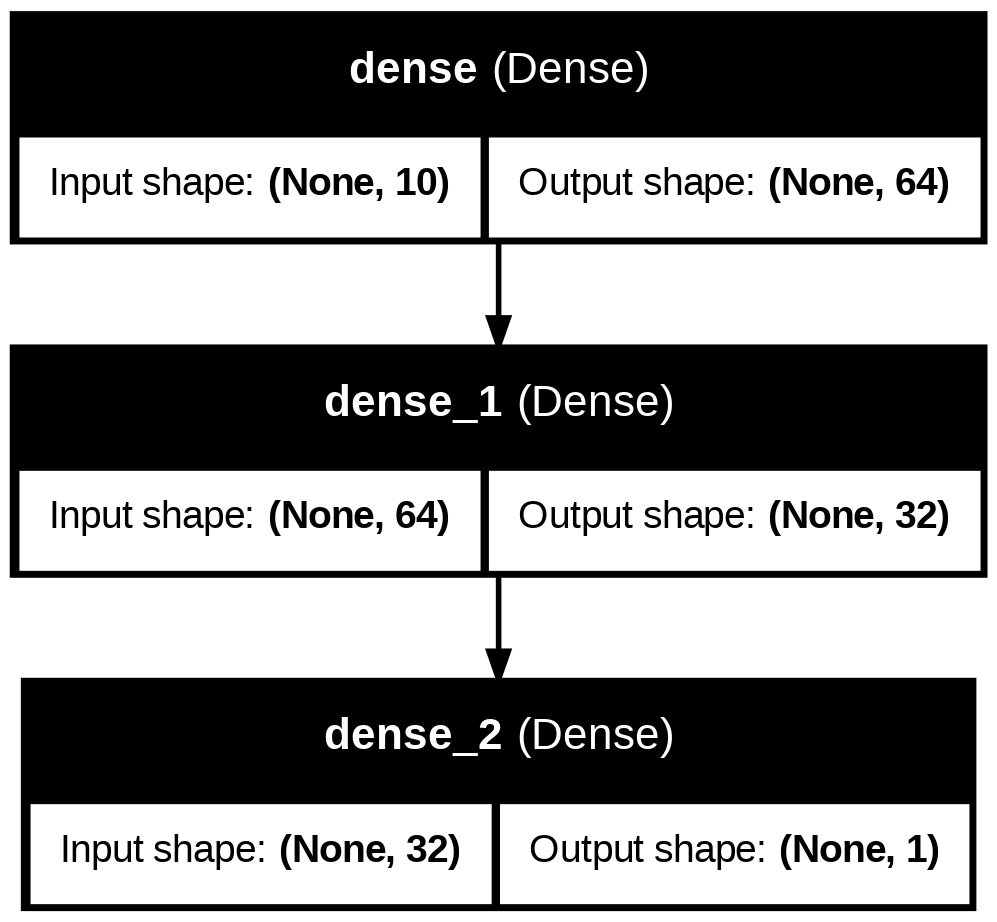

In [ ]:
plot_model(model, show_shapes=True, show_layer_names=True)

### Part c) Training the Model with Dummy Data

In [ ]:
import numpy as np

# Generate dummy data
x_dummy = np.random.rand(1000, 10)  # 1000 samples, 10 features
y_dummy = np.random.randint(0, 2, 1000) # 1000 binary labels (0 or 1) (meaning:0 se start, 2 se kam, size=1000)

In [ ]:
history = model.fit(
    x_dummy,
    y_dummy,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

print(history.history)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4913 - loss: 0.6973 - val_accuracy: 0.4750 - val_loss: 0.7015
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5362 - loss: 0.6883 - val_accuracy: 0.4300 - val_loss: 0.7039
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5450 - loss: 0.6862 - val_accuracy: 0.4350 - val_loss: 0.7069
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5575 - loss: 0.6852 - val_accuracy: 0.4300 - val_loss: 0.7107
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5625 - loss: 0.6840 - val_accuracy: 0.4350 - val_loss: 0.7118
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5625 - loss: 0.6826 - val_accuracy: 0.4100 - val_loss: 0.7148
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5650 - loss: 0.6814 - val_accuracy: 0.4500 - val_loss: 0.7154
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5763 - loss: 0.6809 - val_accuracy: 0.4200 - val_loss

### Part d) Training the Model with a Real Dataset

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 1. Load a real dataset (Breast Cancer Wisconsin)
bc = load_breast_cancer()
X = bc.data  # Features
y = bc.target # Target labels (0 or 1)

# Select the first 10 features to match the model's input shape
# Your model has input_shape=[10], meaning it expects 10 features.
X = X[:, :10]  #All rows but only first 10 columns(features)

print(f"Loaded dataset shape: X={X.shape}, y={y.shape}")

Loaded dataset shape: X=(569, 10), y=(569,)


In [ ]:
# 2. Split the dataset into training and testing sets
# This ensures we evaluate the model on data it hasn't seen during training.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"Testing data shape: X_test={X_test.shape}, y_test={y_test.shape}")

Training data shape: X_train=(455, 10), y_train=(455,)
Testing data shape: X_test=(114, 10), y_test=(114,)


In [ ]:
# 3. Train the model with the new training data
# We use the separate test set for validation during training.
history_data = model.fit(
    X_train,
    y_train,
    epochs=20, # Increased epochs for better learning on real data
    batch_size=32,
    validation_data=(X_test, y_test) # Use separate test set for validation
)

print(history_data.history)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8505 - loss: 0.3736 - val_accuracy: 0.8947 - val_loss: 0.2247
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8484 - loss: 0.3422 - val_accuracy: 0.8860 - val_loss: 0.2295
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8505 - loss: 0.3503 - val_accuracy: 0.8684 - val_loss: 0.2839
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8440 - loss: 0.3830 - val_accuracy: 0.8684 - val_loss: 0.2928
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8681 - loss: 0.3423 - val_accuracy: 0.9298 - val_loss: 0.2378
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8769 - loss: 0.3180 - val_accuracy: 0.8860 - val_loss: 0.2491
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8769 - loss: 0.3362 - val_accuracy: 0.9211 - val_loss: 0.2414
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8747 - loss: 0.3118 - val_accuracy: 0.9035 - val_lo

In [ ]:
# 4. Evaluate the model on the unseen test set
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8947 - loss: 0.2222 

Test Loss: 0.2222
Test Accuracy: 0.8947
